In [2]:
import os

os.getcwd()

'/project/nr_haml2025/endomet/irwl1-adaptation/notebooks'

In [3]:
import pandas

df = pandas.read_csv("../results/resnet20_pruning_config_summary.csv")

In [4]:
df

,configuration,num_runs,epochs_to_target_mean,epochs_to_target_std,iterations_to_target_mean,iterations_to_target_std,avg_training_length_mean,avg_training_length_std,avg_regularization_length_mean,avg_regularization_length_std,sparsity_reached_mean,sparsity_reached_std,test_accuracy_mean,test_accuracy_std
0,smooth_rewind,5,661.8,3.271085,8.0,0.0,18.800,0.370810,61.875,0.250000,92.103730,0.060572,67.186,1.419606
1,smooth_no_rewind,5,884.8,16.006249,8.0,0.0,46.450,2.066473,61.950,0.360122,92.096707,0.071777,67.334,3.909524
2,static_rewind,5,449.6,6.188699,8.0,0.0,19.175,0.504666,34.750,0.385276,92.208326,0.039139,66.122,0.892228
3,static_no_rewind,5,671.2,6.906519,8.0,0.0,47.525,0.714799,34.250,0.293151,92.144522,0.043735,69.750,2.190810


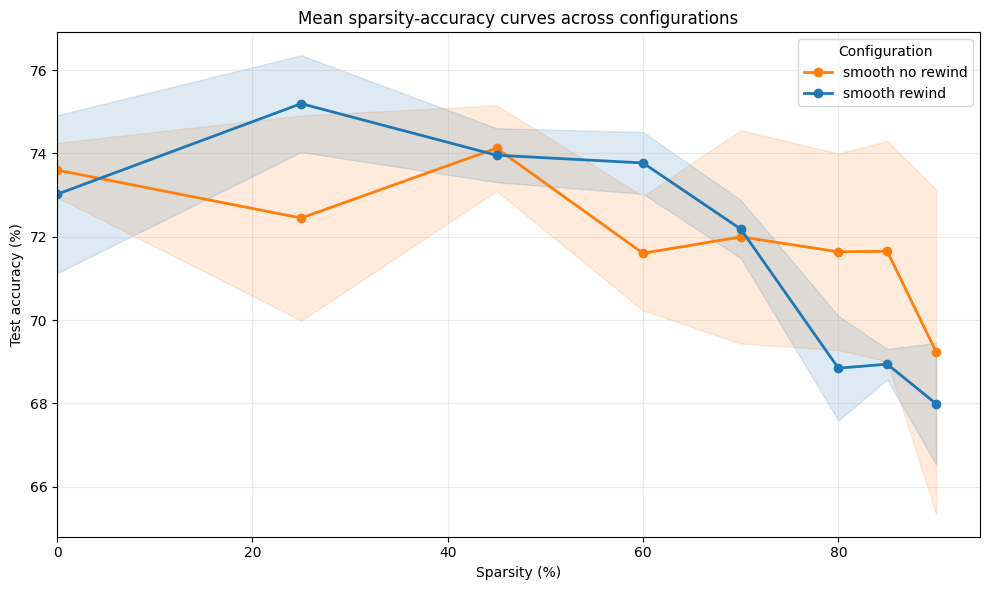

,configuration,sparsity_group,mean_accuracy,std_accuracy,num_points
0,smooth_no_rewind,0.0,73.602,0.650746,5
1,smooth_no_rewind,25.0,72.450,2.462773,5
2,smooth_no_rewind,45.0,74.126,1.030936,5
3,smooth_no_rewind,60.0,71.604,1.373146,5
4,smooth_no_rewind,70.0,71.998,2.560033,5
5,smooth_no_rewind,80.0,71.640,2.357827,5
6,smooth_no_rewind,85.0,71.652,2.645387,5
7,smooth_no_rewind,90.0,69.242,3.891492,10
8,smooth_rewind,0.0,73.020,1.896220,5
9,smooth_rewind,25.0,75.196,1.161112,5


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

all_checkpoints = pd.read_csv("../results/resnet20_pruning_all_checkpoints.csv")

# Group checkpoints that are within 2 percentage points of each other by rounding to the nearest 2% bin.
# This keeps the 0% checkpoint and aligns the sparsity points across runs even when the exact values differ slightly.
all_checkpoints = all_checkpoints.copy()
all_checkpoints["sparsity_group"] = (all_checkpoints["sparsity"] / 5.0).round() * 5.0
all_checkpoints["sparsity_group"] = all_checkpoints["sparsity_group"].clip(lower=0.0)

summary = (
    all_checkpoints
    .groupby(["configuration", "sparsity_group"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", lambda values: values.std(ddof=1)),
        num_points=("accuracy", "size"),
    )
    .sort_values(["configuration", "sparsity_group"])
)

fig, ax = plt.subplots(figsize=(10, 6))
config_colors = {
    "smooth_rewind": "tab:blue",
    "smooth_no_rewind": "tab:orange",
    "static_rewind": "tab:green",
    "static_no_rewind": "tab:red",
}

# filter configurations
summary = summary[summary["configuration"].isin(["smooth_rewind", "smooth_no_rewind"])]

for config_name, config_df in summary.groupby("configuration"):
    config_df = config_df.sort_values("sparsity_group")
    x = config_df["sparsity_group"].to_numpy()
    y = config_df["mean_accuracy"].to_numpy()
    yerr = config_df["std_accuracy"].fillna(0.0).to_numpy()

    ax.plot(
        x,
        y,
        marker="o",
        linewidth=2,
        label=config_name.replace("_", " "),
        color=config_colors.get(config_name),
    )
    ax.fill_between(
        x,
        y - yerr,
        y + yerr,
        alpha=0.15,
        color=config_colors.get(config_name),
    )

ax.set_xlabel("Sparsity (%)")
ax.set_ylabel("Test accuracy (%)")
ax.set_title("Mean sparsity-accuracy curves across configurations")
ax.grid(True, alpha=0.25)
ax.legend(title="Configuration")
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

summary


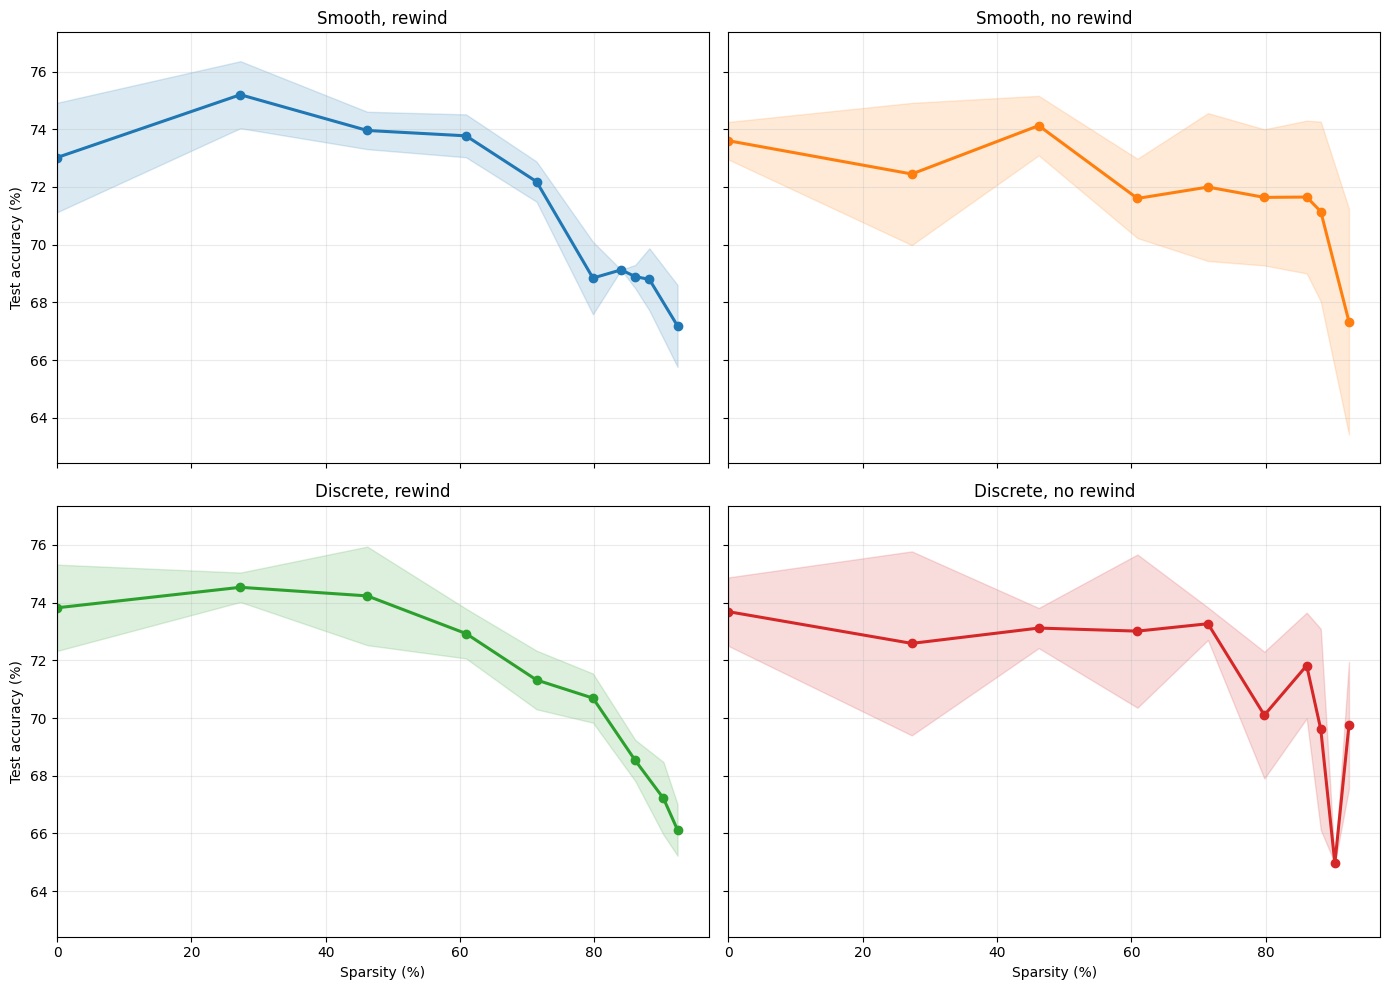

,configuration,sparsity_group,mean_accuracy,std_accuracy,num_points
0,smooth_no_rewind,0.0,73.6020,0.650746,5
1,smooth_no_rewind,27.3,72.4500,2.462773,5
2,smooth_no_rewind,46.2,74.1260,1.030936,5
3,smooth_no_rewind,60.9,71.6040,1.373146,5
4,smooth_no_rewind,71.4,71.9980,2.560033,5
5,smooth_no_rewind,79.8,71.6400,2.357827,5
6,smooth_no_rewind,86.1,71.6520,2.645387,5
7,smooth_no_rewind,88.2,71.1500,3.112523,5
8,smooth_no_rewind,92.4,67.3340,3.909524,5
9,smooth_rewind,0.0,73.0200,1.896220,5


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

checkpoint_df = pd.read_csv("../results/resnet20_pruning_all_checkpoints.csv").copy()
checkpoint_df["sparsity_group"] = (checkpoint_df["sparsity"] / 2.1).round() * 2.1
checkpoint_df["sparsity_group"] = checkpoint_df["sparsity_group"].clip(lower=0.0)

comparison_summary = (
    checkpoint_df
    .groupby(["configuration", "sparsity_group"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        std_accuracy=("accuracy", lambda values: values.std(ddof=1)),
        num_points=("accuracy", "size"),
    )
    .sort_values(["configuration", "sparsity_group"])
)

config_colors = {
    "smooth_rewind": "tab:blue",
    "smooth_no_rewind": "tab:orange",
    "static_rewind": "tab:green",
    "static_no_rewind": "tab:red",
}

config_layout = [
    ("smooth_rewind", "Smooth, rewind"),
    ("smooth_no_rewind", "Smooth, no rewind"),
    ("static_rewind", "Discrete, rewind"),
    ("static_no_rewind", "Discrete, no rewind"),
]

all_y = comparison_summary["mean_accuracy"].to_numpy()
all_yerr = comparison_summary["std_accuracy"].fillna(0.0).to_numpy()
ymin = float(np.min(all_y - all_yerr)) - 1.0
ymax = float(np.max(all_y + all_yerr)) + 1.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (config_name, title) in zip(axes, config_layout):
    config_df = comparison_summary[comparison_summary["configuration"] == config_name].sort_values("sparsity_group")
    x = config_df["sparsity_group"].to_numpy()
    y = config_df["mean_accuracy"].to_numpy()
    yerr = config_df["std_accuracy"].fillna(0.0).to_numpy()
    color = config_colors[config_name]

    ax.plot(x, y, marker="o", linewidth=2.2, color=color)
    ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.16)
    ax.set_title(title)
    ax.set_xlim(left=0)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.25)

for ax in axes[2:]:
    ax.set_xlabel("Sparsity (%)")
for ax in axes[::2]:
    ax.set_ylabel("Test accuracy (%)")

#fig.suptitle("Sparsity-accuracy curves by configuration", y=1.02)
fig.tight_layout()
plt.show()

#comparison_summary
